# SWIRE Coca‑Cola EDA — Individual Notebook

By: Ali Ladha <br>
Date: 2025-09-20  


---



## 1) Business & Analytic Problem

**Business Objective:** Reduce revenue loss by understanding and mitigating cart abandonment on MyCoke360. Identify behaviors that predict abandonment and recovery while determining product patterns.
**Business Problem:** Swire Coca-Cola (Swire) recently launched MyCoke360, a B2B platform for Foodservice
On-Premise (FSOP) customers to purchase Coca-Cola products. Swire is incurring losses each
order cycle due to cart abandonment, where customers add products to their carts but do not
submit orders by the scheduled date. This problem disrupts plant logistics, reduces revenue,
and strains customer relationships.



# 2) Main Questions

1. **How does cart abandonment vary by device type and how can it be reduced?**
2. **Which products appear most frequently in abandoned carts?**




## 3) Data Inventory & Known Limitations

**Primary facts**
- `google_analytics.csv` — website events for MyCoke360 with items & timestamps (EST).  
- `orders.csv` — items ordered by customer/date (one material per row).  
- `sales.csv` — items sold with prices; use **NSI_DEAD_NET** for revenue.

**Key dimensions & helpers**
- `visit_plan.csv` — historical visit plans; anchor date (defines anchor *day-of-week*), order **frequency**.  
- `operating_hours.csv` — current visit plan info.  
- `cutoff_times.csv` — exceptions to default 5pm order cutoff (local time).  
- `customer.csv` — customer attributes (type, sales office).  
- `material.csv` — product attributes (brand, pack, size, flavor).

**Rules (from case)**
- Build **order windows** using anchor date/frequency and **local cutoff time** per sales office.  
- **Abandoned** if cart was added in a window but **no purchase** in that same window; override using `orders` table.  
- Compute per-material **revenue** using daily averages from `sales` (price varies by day/customer).

**Limitations to watch for**
- GA **drops** some events; purchase events may be **missing**.  
- Mismatches between GA add-to-cart, GA purchase, and Orders/Sales; mobile purchase items may be blank.


In [1]:
# 4) Importing Packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.csv as pv
import pyarrow.parquet as pq

import json

pd.set_option('display.float_format', lambda x: '%.4f' % x)  #  scientific notation off



## 5) Load Data

In [2]:
ga = pd.read_csv('google_analytics.csv')
orders = pd.read_csv('orders.csv')
sales = pd.read_csv('sales.csv')
visit_plan = pd.read_csv('visit_plan.csv')
customer = pd.read_csv('customer.csv')
cutoff_times = pd.read_csv('cutoff_times.csv')
operating_hours = pd.read_csv('operating_hours.csv')
materials = pd.read_csv('material.csv')




/var/folders/g1/_r53jbfn2tg_0kcxz7b3cwg40000gn/T/ipykernel_86071/4021526129.py:4: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  visit_plan = pd.read_csv('visit_plan.csv')


In [3]:
ga.head() # This table gives us data on website events on myCoke360. Each row represents a specific event such as a click. It logs the time, page, associated items, etc. 
          # EVENT_TIMESTAMPS are all in EST

orders.head() # This table gives us what items were ordered by which customer and when the order placed. However, orders are broken up such that each row will only have one material id.

sales.head() # This table gives us which items were sold. These items are slightly different than orders due to items being sometimes sold out. This table is used to compute revenue using NSI_DEAD_NET. 

visit_plan.head() # A visit plan is on which day of the week and how often a customer is scheduled to place an order. These visit plans do change. This table gives us the historical visit plans for each customer. The day of the week of the anchor date is the customer’s day they must order by. 

customer.head() # This table gives us information on customers such as where they order from and what type of customer category they are in (restaurant, wholesaler).

cutoff_times.head() #Each sales office has a specific time of day its customers must have their order in by. The default time is 5pm but there are exceptions. This table lists all the exceptions. Use sales office, shipping conditions and distribution mode to join to visit plan table.
                     # IMPORTANT: Cutoff times are local to the customer. Whereas GA event timestamps are in EST. Also If not in table, then cutoff time is 5pm.

operating_hours.head() # This table has similar information as the visit plan table, but it has the current information for the customers.

materials.head() # This table gives us specific information on products. For each material id we have the category, brand, flavor, pack size & type.




,MATERIAL_ID,PACK_TYPE_DESC,TRADE_MARK_DESC,FLAVOUR_DESC,PACK_SIZE_DESC,BEV_CAT_DESC
0,125522,Plastic Bottle - Other,Oliver Originals,Salted Caramel,20 OZ,CORE SPARKLING
1,116974,Styrofoam Lid,Sunny Sip,Passionfruit,24 OZ,NaN
2,113144,Bag-In-Box,Sam's,Bubblegum,2.5 GALLON,JUICES/NECTARS
3,410256,Aluminum Can,Jack's Juices,Cappuccino,12 OZ,CORE SPARKLING
4,146980,Aluminum Can,Oliver Originals,Vanilla Latte,16 OZ,CORE SPARKLING


## 6) Previewing Tables

In [4]:
from IPython.display import display

# Map table names to a Data
tables = {
    'ga': ga,
    'orders': orders,
    'sales': sales,
    'visit_plan': visit_plan,
    'customer': customer,
    'cutoff_times': cutoff_times,
    'operating_hours': operating_hours,
    'materials': materials
}

# Map table names to descriptions
table_descriptions = {
    'ga': "Website events from MyCoke360 (e.g., add-to-cart, purchase, click). Each row is a GA event. EVENT_TIMESTAMP is in EST.",
    'orders': "Items that were ordered by customers. One material ID per row. Used to override GA when purchases are missing.",
    'sales': "Items sold (not necessarily equal to orders if out-of-stock). Used to compute revenue using NSI_DEAD_NET per material/day.",
    'visit_plan': "Historical visit plans per customer. Includes anchor date and order frequency. Determines order windows.",
    'customer': "Customer metadata including sales office, segment (e.g., restaurant), and geography.",
    'cutoff_times': "Sales-office-specific order cutoff times (local to customer). Join on sales office + shipping + mode. Default is 5pm if not listed.",
    'operating_hours': "Current visit plan info. Similar to visit_plan but up-to-date as of now.",
    'materials': "Product metadata: material category, brand, flavor, pack size/type for each material ID."
}

# Display loop
for name, df in tables.items():
    print(f"\n Table: `{name}` — shape: {df.shape}")
    print(f"Description: {table_descriptions.get(name, 'No description available.')}\n")
    display(df.head())
    display(df.info())



 Table: `ga` — shape: (3704088, 10)
Description: Website events from MyCoke360 (e.g., add-to-cart, purchase, click). Each row is a GA event. EVENT_TIMESTAMP is in EST.



,CUSTOMER_ID,EVENT_DATE,EVENT_TIMESTAMP,EVENT_NAME,DEVICE_CATEGORY,DEVICE_MOBILE_BRAND_NAME,DEVICE_OPERATING_SYSTEM,EVENT_PAGE_NAME,EVENT_PAGE_TITLE,ITEMS
0,501508595,2025-04-07,2025-04-07T14:57:40.713Z,view_search_results,mobile,Samsung,Android,Product List,NaN,[]
1,501730915,2025-04-07,2025-04-07T19:28:54.546Z,view_item_list,desktop,Google,Windows,NaN,Search,"[{""item_id"":""158520"",""quantity"":""1""},{""item_id..."
2,501567329,2025-04-07,2025-04-07T21:40:56.281Z,purchase,desktop,Google,Windows,MyCoke Orders - Purchase Success,Order,"[{""item_id"":""138335"",""quantity"":""2""},{""item_id..."
3,501765083,2025-04-08,2025-04-08T06:06:36.717Z,user_engagement,mobile,Apple,iOS,NaN,NaN,[]
4,501707837,2025-04-08,2025-04-08T18:12:10.511Z,view_item_list,desktop,Google,Windows,MyCoke Orders,Category: All Products,"[{""item_id"":""412588"",""quantity"":""1""},{""item_id..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3704088 entries, 0 to 3704087
Data columns (total 10 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   CUSTOMER_ID               int64 
 1   EVENT_DATE                object
 2   EVENT_TIMESTAMP           object
 3   EVENT_NAME                object
 4   DEVICE_CATEGORY           object
 5   DEVICE_MOBILE_BRAND_NAME  object
 6   DEVICE_OPERATING_SYSTEM   object
 7   EVENT_PAGE_NAME           object
 8   EVENT_PAGE_TITLE          object
 9   ITEMS                     object
dtypes: int64(1), object(9)
memory usage: 282.6+ MB


None


 Table: `orders` — shape: (1662157, 7)
Description: Items that were ordered by customers. One material ID per row. Used to override GA when purchases are missing.



...

None


 Table: `materials` — shape: (1252, 6)
Description: Product metadata: material category, brand, flavor, pack size/type for each material ID.



,MATERIAL_ID,PACK_TYPE_DESC,TRADE_MARK_DESC,FLAVOUR_DESC,PACK_SIZE_DESC,BEV_CAT_DESC
0,125522,Plastic Bottle - Other,Oliver Originals,Salted Caramel,20 OZ,CORE SPARKLING
1,116974,Styrofoam Lid,Sunny Sip,Passionfruit,24 OZ,NaN
2,113144,Bag-In-Box,Sam's,Bubblegum,2.5 GALLON,JUICES/NECTARS
3,410256,Aluminum Can,Jack's Juices,Cappuccino,12 OZ,CORE SPARKLING
4,146980,Aluminum Can,Oliver Originals,Vanilla Latte,16 OZ,CORE SPARKLING


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1252 entries, 0 to 1251
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   MATERIAL_ID      1252 non-null   int64 
 1   PACK_TYPE_DESC   1252 non-null   object
 2   TRADE_MARK_DESC  1252 non-null   object
 3   FLAVOUR_DESC     1252 non-null   object
 4   PACK_SIZE_DESC   1252 non-null   object
 5   BEV_CAT_DESC     1118 non-null   object
dtypes: int64(1), object(5)
memory usage: 58.8+ KB


None

# 7) Data Cleaning


- Cleaning the data is an essential step before performing the EDA
- This would prevent us from analyzing data that has
    - Incorrect data types
    - Missing values
    - Outliers


- Secondly we will change the column names to lowercase format

In [5]:
# tables = {
#     'ga': ga,
#     'orders': orders,
#     'sales': sales,
#     'visit_plan': visit_plan,
#     'customer': customer,
#     'cutoff_times': cutoff_times,
#     'operating_hours': operating_hours,
#     'materials': materials
# }

# Lowercase all column names
for name, df in tables.items():
    df.columns = df.columns.str.lower()



## 7.1) Google Analytics

a) Fixing data types for GA Table


In [6]:

# 2 columns need to be fixed: EVENT_DATE and EVENT_TIMESTAMP

# EVENT_DATE
ga['event_date'] = pd.to_datetime(ga['event_date'])


# EVENT_TIMESTAMP changing it to UTC
ga['event_timestamp'] = pd.to_datetime(ga['event_timestamp'], utc=True)
ga.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3704088 entries, 0 to 3704087
Data columns (total 10 columns):
 #   Column                    Dtype              
---  ------                    -----              
 0   customer_id               int64              
 1   event_date                datetime64[ns]     
 2   event_timestamp           datetime64[ns, UTC]
 3   event_name                object             
 4   device_category           object             
 5   device_mobile_brand_name  object             
 6   device_operating_system   object             
 7   event_page_name           object             
 8   event_page_title          object             
 9   items                     object             
dtypes: datetime64[ns, UTC](1), datetime64[ns](1), int64(1), object(7)
memory usage: 282.6+ MB


b) Evaluating Missing data and Selecting relevant columns

In [7]:
# Changing items = [] to NaN
# This is to reflect how GA does not capture item purchases for mobile orders as clarified by Swire

ga['items'] = ga['items'].replace('[]', np.nan)


In [8]:
# Transforming the items column from a JSON dictionary to 2 columns: material_id and order_quantity

import json
import numpy as np
import pandas as pd

# STEP 0: Replace '[]' with NaN so it's treated as truly missing (GA drops mobile item data)
ga['items'] = ga['items'].replace('[]', np.nan)

# STEP 1: Create a stable event ID for every GA row — this helps us merge exploded items back later
ga_full = ga.copy()
ga_full['event_row_id'] = ga_full.index  # unique row ID

# STEP 2: Work only with rows that actually contain items
# We’ll parse and explode these, but leave the others untouched
ga_items = ga_full[ga_full['items'].notna()].copy()

# STEP 3: Parse the JSON string in 'items' into a real Python list of dictionaries
parsed_items = []
for row in ga_items['items']:
    try:
        parsed = json.loads(row) if isinstance(row, str) else np.nan
        parsed_items.append(parsed if isinstance(parsed, list) else np.nan)
    except Exception:
        parsed_items.append(np.nan)
ga_items['items_parsed'] = parsed_items

# STEP 4: Explode the list of dictionaries so each row has ONE item
# This turns multi-item events into multiple rows
ga_items = ga_items.explode('items_parsed', ignore_index=True)

# STEP 5: Pull out 'item_id' and 'quantity' from each dictionary into clean new columns
ga_items['material_id'] = ga_items['items_parsed'].apply(
    lambda x: x.get('item_id') if isinstance(x, dict) else np.nan
)
ga_items['order_quantity'] = ga_items['items_parsed'].apply(
    lambda x: x.get('quantity') if isinstance(x, dict) else np.nan
)

# STEP 6: Convert types to numeric
# This ensures no decimal places, and keeps missing values safely
ga_items['material_id'] = pd.to_numeric(ga_items['material_id'], errors='coerce').astype('Int64')
ga_items['order_quantity'] = pd.to_numeric(ga_items['order_quantity'], errors='coerce').astype('Int64')

# STEP 7: Keep only the event ID and the two new item-level columns
ga_items = ga_items[['event_row_id', 'material_id', 'order_quantity']]

# STEP 8: Merge the item data back into the full GA table
# This preserves ALL rows (including mobile orders with missing items)
ga = ga_full.merge(ga_items, on='event_row_id', how='left')

# Dropping the extra columns made for merging
ga.drop(columns='event_row_id', inplace=True)


- The items column has now been cleaned. Two columns have been created alongside it namely: material_id and quantity. This may be used upon joining the datasets.

In [9]:
ga.head()

,customer_id,event_date,event_timestamp,event_name,device_category,device_mobile_brand_name,device_operating_system,event_page_name,event_page_title,items,material_id,order_quantity
0,501508595,2025-04-07,2025-04-07 14:57:40.713000+00:00,view_search_results,mobile,Samsung,Android,Product List,NaN,NaN,<NA>,<NA>
1,501730915,2025-04-07,2025-04-07 19:28:54.546000+00:00,view_item_list,desktop,Google,Windows,NaN,Search,"[{""item_id"":""158520"",""quantity"":""1""},{""item_id...",158520,1
2,501730915,2025-04-07,2025-04-07 19:28:54.546000+00:00,view_item_list,desktop,Google,Windows,NaN,Search,"[{""item_id"":""158520"",""quantity"":""1""},{""item_id...",158213,1
3,501730915,2025-04-07,2025-04-07 19:28:54.546000+00:00,view_item_list,desktop,Google,Windows,NaN,Search,"[{""item_id"":""158520"",""quantity"":""1""},{""item_id...",158209,1
4,501567329,2025-04-07,2025-04-07 21:40:56.281000+00:00,purchase,desktop,Google,Windows,MyCoke Orders - Purchase Success,Order,"[{""item_id"":""138335"",""quantity"":""2""},{""item_id...",138335,2


In [10]:
# Calculating overall nulls

# Step 1: Obtaining Null %
null_ga = (ga.isnull().sum() / len(ga) * 100).sort_values(ascending=False).round(2)

# Step 2: We will convert it to a % via making the output a string
null_ga = null_ga.astype(str) + '%'

# Step 3: Displaying the output
display(null_ga)




material_id                 35.94%
items                       34.29%
order_quantity              34.29%
event_page_name              22.8%
event_page_title             4.83%
device_mobile_brand_name     0.95%
customer_id                   0.0%
event_date                    0.0%
event_timestamp               0.0%
event_name                    0.0%
device_category               0.0%
device_operating_system       0.0%
dtype: object

- There are multiple records that are NaN for material_id and order_quantity because either a purchase was not made or it was a mobile order
- Therefore, we will not remove these records for now


c) Outlier Analysis


In [11]:
ga.describe() 

# order uanttiy has outliers
# The maximum quantity ever ordered was 37,350 which cannot be possible.

# Finding the amount of orders that have a quantity > 500

ga.loc[ga['order_quantity'] > 500].shape # 188 orders have a quantity > 500
ga.loc[ga['order_quantity'] <= 500].shape # 5565973 orders have a quantity <= 500

print(f'The number of orders that had more than 500 units was {ga.loc[ga['order_quantity'] > 500].shape[0]} orders.\nThe number of orders that have <= 500 units was {ga.loc[ga['order_quantity'] <= 500].shape[0]} orders.\nWe will limit the order quantity to upto 500 units')

# Limiting order_quantity to <=500
ga = ga[ga['order_quantity'] <= 500]




The number of orders that had more than 500 units was 188 orders.
The number of orders that have <= 500 units was 5565973 orders.
We will limit the order quantity to upto 500 units


## 7.2) Orders



a) Fixing data types for Orders


In [12]:
# ---- Fix columns in ORDERS ----
# Columns to fix: created_date_est, created_date_utc, material_id, order_quantity

# created_date_est  → datetime
orders['created_date_est'] = pd.to_datetime(orders['created_date_est'])

# created_date_utc → timezone-aware UTC
orders['created_date_utc'] = pd.to_datetime(orders['created_date_utc'], utc=True)

# material_id → integer 
orders['material_id'] = pd.to_numeric(orders['material_id'], errors='coerce').astype('Int64')

# order_quantity → integer
orders['order_quantity'] = pd.to_numeric(orders['order_quantity'], errors='coerce').astype('Int64')

orders.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1662157 entries, 0 to 1662156
Data columns (total 7 columns):
 #   Column            Non-Null Count    Dtype              
---  ------            --------------    -----              
 0   customer_id       1662157 non-null  int64              
 1   created_date_est  1662157 non-null  datetime64[ns]     
 2   created_date_utc  1662157 non-null  datetime64[ns, UTC]
 3   material_id       1661962 non-null  Int64              
 4   order_quantity    1662157 non-null  Int64              
 5   order_type        1662157 non-null  object             
 6   plant_id          1662146 non-null  object             
dtypes: Int64(2), datetime64[ns, UTC](1), datetime64[ns](1), int64(1), object(2)
memory usage: 91.9+ MB


b) Evaluating Missing data and Selecting relevant columns

In [13]:
display(orders.isna().sum())
print(f'The shape of the orders table {orders.shape}')



customer_id           0
created_date_est      0
created_date_utc      0
material_id         195
order_quantity        0
order_type            0
plant_id             11
dtype: int64

The shape of the orders table (1662157, 7)


In [14]:
# We will remove the null material_ids and plant_id records given that only a few records are lost

orders = orders[orders['material_id'].notna() & orders['plant_id'].notna()]

- We will retain all columns for now. Order_type and plant_id was initially considered to be removed; however, it may be a predictor of cart abandonment

c) Outlier analysis

In [15]:

orders['order_quantity'].describe()


count   1661962.0000
mean          2.8106
std          12.9345
min           1.0000
25%           1.0000
50%           1.0000
75%           2.0000
max        2000.0000
Name: order_quantity, dtype: Float64

In [16]:
# Viewing Number of orders with quantity > 100
orders[orders['order_quantity'] > 100].shape


print(f'The mean order quantity is around 3.\nThe max order quantity is 2000. The total records of the dataset is {orders.shape[0]}.\nThe number of orders past 100 is very small at {orders[orders['order_quantity'] > 100].shape[0]} records.\nJust because a customer orders a large quantity, does not mean its an outlier that should be deleted from the dataset.\nThe outlier can be explained due to the customer type itself.')



The mean order quantity is around 3.
The max order quantity is 2000. The total records of the dataset is 1661962.
The number of orders past 100 is very small at 3400 records.
Just because a customer orders a large quantity, does not mean its an outlier that should be deleted from the dataset.
The outlier can be explained due to the customer type itself.


## 7.3) Sales

a) Fixing data types for Sales


In [17]:
sales.head()

,customer_id,posting_date,material_id,gross_profit_dead_net,physical_volume,nsi,nsi_dead_net,gross_profit
0,501473438,2024-06-10,123159,53.6000,8.0000,111.0400,111.0400,53.6000
1,501473438,2024-06-10,115584,21.7600,4.0000,51.1200,51.1200,21.7600
2,501502460,2024-06-10,103996,-0.8900,2.0000,210.8000,210.8000,-0.8900
3,501168843,2024-06-10,156091,10.2000,2.0000,30.5000,30.5000,10.2000
4,501583464,2024-06-10,119827,42.1500,4.0000,98.4000,88.4000,52.1500


In [18]:
# physical volume contains decimals so we will keep it as float

# posting_date to a datetime
sales['posting_date'] = pd.to_datetime(sales['posting_date'])

sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499787 entries, 0 to 499786
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   customer_id            499787 non-null  int64         
 1   posting_date           499787 non-null  datetime64[ns]
 2   material_id            499787 non-null  int64         
 3   gross_profit_dead_net  499787 non-null  float64       
 4   physical_volume        499787 non-null  float64       
 5   nsi                    499787 non-null  float64       
 6   nsi_dead_net           499787 non-null  float64       
 7   gross_profit           499787 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 30.5 MB


b) Evaluating Missing data and Selecting relevant columns

In [19]:
sales.head()

,customer_id,posting_date,material_id,gross_profit_dead_net,physical_volume,nsi,nsi_dead_net,gross_profit
0,501473438,2024-06-10,123159,53.6000,8.0000,111.0400,111.0400,53.6000
1,501473438,2024-06-10,115584,21.7600,4.0000,51.1200,51.1200,21.7600
2,501502460,2024-06-10,103996,-0.8900,2.0000,210.8000,210.8000,-0.8900
3,501168843,2024-06-10,156091,10.2000,2.0000,30.5000,30.5000,10.2000
4,501583464,2024-06-10,119827,42.1500,4.0000,98.4000,88.4000,52.1500


In [20]:
sales.isna().sum() # no nulls

# Removing non DEAD NET alternative metrics per Swire team request

sales = sales.drop(columns = ['nsi', 'gross_profit'])

c) Outlier analysis

In [21]:
display(sales.describe())

print(f'There are {sales.loc[sales['nsi_dead_net'] < 0].shape[0]} negative revenue values in the nsi_dead_net_column. This may be due to losses. We will remove them')

sales = sales[sales['nsi_dead_net'] >= 0]


,customer_id,posting_date,material_id,gross_profit_dead_net,physical_volume,nsi_dead_net
count,499787.0000,499787,499787.0000,499787.0000,499787.0000,499787.0000
mean,543088877.9471,2024-11-25 15:45:21.917135872,148828.4826,71.2581,6.7799,179.2076
min,500245685.0000,2024-05-31 00:00:00,100722.0000,-5911.5000,1.0420,-201.6000
25%,501267557.0000,2024-08-22 00:00:00,116149.0000,16.7500,2.0000,49.3500
50%,501656558.0000,2024-11-21 00:00:00,129252.0000,32.1200,2.0000,76.6800
75%,600079611.0000,2025-03-03 00:00:00,151817.0000,58.6600,4.0000,141.0000
max,600975280.0000,2025-05-24 00:00:00,700462.0000,16797.2100,2000.0000,61614.0000
std,48928927.6762,NaN,75610.3699,206.9144,22.5831,565.2288


There are 78 negative revenue values in the nsi_dead_net_column. This may be due to losses. We will remove them


## 7.4) Visit plan

a) Fixing data types for Visit Plan

In [22]:
# Frequency has dirty data.
display(visit_plan['frequency'].unique())

# it should be 0# -> days
#01 -> 7
#02 -> 14
#04 - 28

# Every first week -> 7
# Every second week -> 14
# Every third week -> 21
# Every fourth week -> 28

# 1.0 -> 7
# 2.0 -> 14
# 3.0 -> 21


# this field looks to be entered in directly by sales representatives. Therefore, there are several inconsistencies. We will need to clean this.

import pandas as pd
import numpy as np

# Step 1: Work on a copy
vp = visit_plan.copy()

# Step 2: Keep original messy column just in case
vp.rename(columns={'frequency': 'frequency_raw'}, inplace=True)

# Step 3: Normalize frequency values
# - Convert to string
# - Strip spaces
# - Remove decimals (convert float-looking codes like 1.0 → '01')
vp['frequency'] = vp['frequency_raw'].astype(str).str.strip()

# Remove trailing '.0' if it looks like a number
vp['frequency'] = vp['frequency'].str.replace(r'\.0$', '', regex=True)

# Pad single-digit numbers with a 0 (so 1 → 01, 2 → 02)
vp['frequency'] = vp['frequency'].apply(lambda x: f"0{x}" if x.isdigit() and len(x) == 1 else x)

# Convert to uppercase to handle text like "Every Second Week On"
vp['frequency'] = vp['frequency'].str.upper()

# Step 4: Create a new column for frequency in days (nullable integer)
vp['frequency_days'] = pd.Series(pd.array([pd.NA] * len(vp), dtype='Int64'))

# Step 5: Map known numeric codes to days
code_map = {
    '01': 7,
    '02': 14,
    '03': 21,
    '04': 28,
    '05': 35,
    '06': 42,
    '08': 56,
    '10': 70
}
vp.loc[vp['frequency'].isin(code_map), 'frequency_days'] = (
    vp['frequency'].map(code_map).astype('Int64')
)

# Step 6: Handle "Every <Ordinal> Week On" style patterns
ordinal_map = {
    'FIRST': 1, 'SECOND': 2, 'THIRD': 3, 'FOURTH': 4, 'FIFTH': 5,
    'SIXTH': 6, 'SEVENTH': 7, 'EIGHTH': 8, 'NINTH': 9, 'TENTH': 10
}

# Extract the ordinal word from phrases like "EVERY FOURTH WEEK ON"
pattern = r'^EVERY\s+([A-Z]+)\s+WEEK'
matches = vp['frequency'].str.extract(pattern, expand=False)

# Map ordinal words to days (weeks × 7)
vp.loc[matches.notna(), 'frequency_days'] = (
    matches.map(ordinal_map).astype('Int64') * 7
)


pct_unmapped = vp['frequency_days'].isna().mean() * 100
print(f"Percent of rows left as missing (not mapped): {pct_unmapped:.2f}%")

# Assign back to visit_plan
visit_plan = vp


array(['02', '01', '04', 'Every Second Week On', 'Every Week On',
       'Every Fourth Week On', 'Every Third Week On',
       'Every Tenth Week On', '03', 'Every Fifth Week On',
       'Every Eighth Week On', nan, 'Not Applicable',
       'Every Sixth Week On', '1 ', '2 ', '4 ', '3 ', '10', '05', ' 1',
       '5 ', '8 ', '08', '06', 1.0, 4.0, 2.0, 3.0, 10.0, 8.0, 5.0, 6.0],
      dtype=object)

Percent of rows left as missing (not mapped): 10.77%


In [23]:
# dropping tables frequency_raw and original frequency. Renaming frequency_days to frequency

visit_plan = visit_plan.drop(columns=['frequency_raw', 'frequency'])
visit_plan = visit_plan.rename(columns={'frequency_days': 'frequency'})


In [24]:
display(visit_plan['frequency'].unique())

<IntegerArray>
[14, 7, 28, <NA>, 21, 70, 35, 56, 42]
Length: 9, dtype: Int64

In [25]:
display(visit_plan.info())
display(visit_plan.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11657401 entries, 0 to 11657400
Data columns (total 9 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   customer_id               int64 
 1   elt_ts                    object
 2   snapshot_date             object
 3   anchor_date               object
 4   sales_office              object
 5   sales_office_desc         object
 6   distribution_mode         object
 7   shipping_conditions_desc  object
 8   frequency                 Int64 
dtypes: Int64(1), int64(1), object(7)
memory usage: 811.6+ MB


None

,customer_id,elt_ts,snapshot_date,anchor_date,sales_office,sales_office_desc,distribution_mode,shipping_conditions_desc,frequency
0,500405850,2021-12-14T05:49:54.551Z,2021-12-13,2020-07-20,G133,"Glenwood Springs, CO",SL,48 Hours,14
1,500286563,2021-12-14T05:49:54.551Z,2021-12-13,2019-11-04,G236,"Denver, CO",OF,48 Hours,7
2,600057832,2021-12-14T05:49:54.551Z,2021-12-13,2021-08-02,G111,"Draper, UT",SL,48 Hours,7
3,500431853,2021-12-14T05:49:54.551Z,2021-12-13,2020-04-06,G111,"Draper, UT",SL,48 Hours,7
4,600076074,2021-12-14T05:49:54.551Z,2021-12-13,2019-06-07,G142,"Pocatello, ID",EZ,24 Hours,7


In [26]:
# ---- Fix columns in VISIT_PLAN ----

# 1. Clean distribution_mode and map to correct description
# Keep the same column name
visit_plan['distribution_mode'] = visit_plan['distribution_mode'].astype(str).str.strip().str.upper()

distribution_map = {
    'OF': 'OFS',
    'RD': 'Rapid Delivery',
    'EZ': 'E Pallet',
    'SL': 'Sideload',
    'NS': 'Night Sideload',
    'FS': 'Full Service',
    'NR': 'Night Rapid Delivery',
    'NO': 'Night OFS',
    'SE': 'Special Events',
    'BK': 'Bulk Distribution'
}

visit_plan['distribution_mode'] = visit_plan['distribution_mode'].map(distribution_map)

# 2. Convert elt_ts to full datetime
visit_plan['elt_ts'] = pd.to_datetime(visit_plan['elt_ts'], errors='coerce')

# 3. Convert snapshot_date and anchor_date to date only
visit_plan['snapshot_date'] = pd.to_datetime(visit_plan['snapshot_date'], errors='coerce')
visit_plan['anchor_date'] = pd.to_datetime(visit_plan['anchor_date'], errors='coerce')

# 4. Clean shipping_conditions_desc to extract number of hours (keep same column name)
# Normalize to lowercase and strip spaces
visit_plan['shipping_conditions_desc'] = visit_plan['shipping_conditions_desc'].astype(str).str.strip().str.lower()

# Extract hours from patterns like '48 hours', 'dropsite 72 hours', etc.
hours = visit_plan['shipping_conditions_desc'].str.extract(r'(\d+)\s*hour')[0]

# Replace column with extracted numeric hours as Int64 (nullable integer)
visit_plan['shipping_conditions_desc'] = pd.to_numeric(hours, errors='coerce').astype('Int64')



In [27]:
visit_plan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11657401 entries, 0 to 11657400
Data columns (total 9 columns):
 #   Column                    Dtype              
---  ------                    -----              
 0   customer_id               int64              
 1   elt_ts                    datetime64[ns, UTC]
 2   snapshot_date             datetime64[ns]     
 3   anchor_date               datetime64[ns]     
 4   sales_office              object             
 5   sales_office_desc         object             
 6   distribution_mode         object             
 7   shipping_conditions_desc  Int64              
 8   frequency                 Int64              
dtypes: Int64(2), datetime64[ns, UTC](1), datetime64[ns](2), int64(1), object(3)
memory usage: 822.7+ MB


b) Evaluating Missing data and Selecting relevant columns

In [28]:
# Null percentages
visit_plan_null = visit_plan.isnull().sum() / len(visit_plan) * 100
visit_plan_null = round(visit_plan_null,2).sort_values(ascending=False)

visit_plan_null




frequency                  10.7700
distribution_mode           0.1100
anchor_date                 0.1000
customer_id                 0.0000
elt_ts                      0.0000
snapshot_date               0.0000
sales_office                0.0000
sales_office_desc           0.0000
shipping_conditions_desc    0.0000
dtype: float64

- We are missing around 11% of frequency values for customers. This is normal considering that the data was initially entered by sales representatives without data validation.

c) Outlier Analysis

In [29]:
visit_plan.describe()

,customer_id,snapshot_date,anchor_date,shipping_conditions_desc,frequency
count,11657401.0000,11657400,11645293,11657338.0000,10402277.0000
mean,537402568.9680,2023-12-08 21:29:46.996345856,2024-01-23 01:45:54.628742400,46.2831,10.8436
min,500245685.0000,2021-11-11 00:00:00,1995-01-01 00:00:00,24.0000,7.0000
25%,501030455.0000,2023-01-14 00:00:00,2020-07-27 00:00:00,48.0000,7.0000
50%,501462673.0000,2024-01-08 00:00:00,2022-05-09 00:00:00,48.0000,7.0000
75%,600071729.0000,2024-11-15 00:00:00,2023-08-07 00:00:00,48.0000,14.0000
max,600975318.0000,2025-08-22 00:00:00,2202-06-08 00:00:00,72.0000,70.0000
std,47781858.7716,NaN,NaN,6.8752,7.6259


- Outliers have been detected for the anchor date. We have a column where the anchor date is 2202
- However, anchor date is not an outlier iteself.
- Per the data dictionary, Anchor_Date is the Day of the week that customers receive their orders
- Therefore we will remove anchor_date records past 2025-08-30

In [30]:
visit_plan = visit_plan[visit_plan['anchor_date'] <= '2025-08-30']



# 7.5) Customer

a) Fixing data types for customer

In [31]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6334 entries, 0 to 6333
Data columns (total 7 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   sales_office                            6334 non-null   object
 1   customer_number                         6334 non-null   int64 
 2   sales_office_description                6334 non-null   object
 3   distribution_mode_description           6330 non-null   object
 4   shipping_conditions_description         6334 non-null   object
 5   cold_drink_channel_description          6334 non-null   object
 6   customer_sub_trade_channel_description  6334 non-null   object
dtypes: int64(1), object(6)
memory usage: 346.5+ KB


b) Evaluating Missing data and Selecting relevant columns

In [32]:
customer.isnull().sum()

sales_office                              0
customer_number                           0
sales_office_description                  0
distribution_mode_description             4
shipping_conditions_description           0
cold_drink_channel_description            0
customer_sub_trade_channel_description    0
dtype: int64

- No null values for the customer table

c) Outlier Analysis

- No numerical outliers as the only numeric is customer_number

 ## 7.6) Cutoff_times

a) Fixing data types for cutoff_times

In [33]:
cutoff_times.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   sales_office             220 non-null    object
 1   plant_id                 220 non-null    object
 2   cutofftime__c            220 non-null    object
 3   shipping_condition_time  220 non-null    object
 4   distribution_mode        220 non-null    object
dtypes: object(5)
memory usage: 8.7+ KB


a) Fixing datatypes for cutoff_times


In [34]:
cutoff_times['shipping_condition_time'].unique()

array(['72hrs', '48hrs', '24hrs'], dtype=object)

In [35]:
# Removing hrs part
cutoff_times['shipping_condition_time'] = cutoff_times['shipping_condition_time'].str.replace('72hrs', '72')
cutoff_times['shipping_condition_time'] = cutoff_times['shipping_condition_time'].str.replace('48hrs', '48')
cutoff_times['shipping_condition_time'] = cutoff_times['shipping_condition_time'].str.replace('24hrs', '24')


In [36]:
# Changing to int
cutoff_times['shipping_condition_time'] = cutoff_times['shipping_condition_time'].astype('int64')

b) Evaluating Missing data and Selecting relevant columns

In [37]:
cutoff_times.isnull().sum()

# No Nulls

sales_office               0
plant_id                   0
cutofftime__c              0
shipping_condition_time    0
distribution_mode          0
dtype: int64

 ## 7.7) Operating Hours

a) Fixing data types for Operating Hours

In [38]:
operating_hours.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6202 entries, 0 to 6201
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_number      6202 non-null   int64 
 1   frequency            6202 non-null   object
 2   delivery_anchor_day  6202 non-null   object
 3   calling_anchor_date  6202 non-null   object
dtypes: int64(1), object(3)
memory usage: 193.9+ KB


In [39]:
# Frequency for this table is different than visit plan as this table includes the current information rather than historical
# so i will clean it
operating_hours.frequency.unique()



# 1. Converting to standard formats
operating_hours['frequency'] = operating_hours['frequency'].astype(str).str.strip().str.title()

# 2. Map to number of days
frequency_map = {
    'Every Week': 7,
    'Every 2 Weeks': 14,
    'Every 3 Weeks': 21,
    'Every 4 Weeks': 28
}

# 3. Replace values directly in the same column (convert to Int64)
operating_hours['frequency'] = operating_hours['frequency'].map(frequency_map).astype('Int64')




In [40]:
# Changing calling_anchor_date to datetime

# calling_anchor_date → convert to datetime
operating_hours['calling_anchor_date'] = pd.to_datetime(operating_hours['calling_anchor_date'], errors='coerce')

operating_hours.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6202 entries, 0 to 6201
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   customer_number      6202 non-null   int64         
 1   frequency            6202 non-null   Int64         
 2   delivery_anchor_day  6202 non-null   object        
 3   calling_anchor_date  6202 non-null   datetime64[ns]
dtypes: Int64(1), datetime64[ns](1), int64(1), object(1)
memory usage: 200.0+ KB


b) Evaluating Missing data and Selecting relevant columns

In [41]:
operating_hours.isnull().sum()

#No Nulls

customer_number        0
frequency              0
delivery_anchor_day    0
calling_anchor_date    0
dtype: int64

# 7.8) Materials

a) Fixing data types for Materials

In [42]:
materials.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1252 entries, 0 to 1251
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   material_id      1252 non-null   int64 
 1   pack_type_desc   1252 non-null   object
 2   trade_mark_desc  1252 non-null   object
 3   flavour_desc     1252 non-null   object
 4   pack_size_desc   1252 non-null   object
 5   bev_cat_desc     1118 non-null   object
dtypes: int64(1), object(5)
memory usage: 58.8+ KB


In [43]:
materials['pack_size_desc'].unique()

# there are many times of weights. Most of them are in 'OZ' but they are weights in lb and gallons as well.
# One of the pack is also 0 ML which is not possible. That record will be dropped




# dropping 0 ml records
materials = materials[materials['pack_size_desc'] != '0 ML']


In [44]:
materials['pack_size_desc'].unique()

array(['20 OZ', '24 OZ', '2.5 GALLON', '12 OZ', '16 OZ', '13.7 OZ',
       '5 GALLON', '11 OZ', '19.2 OZ', '22 OZ', '23 OZ', '1.25 LTR',
       '32 OZ', '21 OZ', '1 LTR', '28 OZ', '7.5 OZ', '23.7 OZ', '2 LTR',
       '20 POUND', '16.9 OZ', '40 Oz', '355 ML', '15.5 OZ', '44 OZ',
       '46 Ounce', '15 OZ', '500 ML', '7.1 OZ', '52 OUNCE', '10.1 OZ',
       '2.5 GALLON FROZEN', '8 OZ', '10 OZ', '14 OZ', '11.5 OZ',
       '18.6 OZ', '59 OZ', '13.5 OZ', '18.5 OZ', '34.5 OZ', '36 OZ',
       '33.8 OZ', '1.5 LTR', '620 ML', '35 POUND', '1.11 KG', '320 ML',
       '1150 GM', '9 OZ', '25.4 OZ', '1 GALLON', '26 OZ', '64 OZ',
       'Not Applicable', '18 OZ', '7.7 DRY OZ', '50 POUND'], dtype=object)

In [45]:
import numpy as np
import pandas as pd
import re

# Step 1: Copy and normalize text
materials['pack_size_clean'] = materials['pack_size_desc'].astype(str).str.strip().str.upper()

# Step 2: Map known textual noise to NaN
materials['pack_size_clean'] = materials['pack_size_clean'].replace({
    'NOT APPLICABLE': np.nan
})

# Step 3: Extract numeric value and unit separately
# Numeric value
materials['pack_value'] = materials['pack_size_clean'].str.extract(r'(\d+(?:\.\d+)?)', expand=False).astype(float)

# Unit: capture from a controlled vocabulary anywhere in the string
materials['pack_unit'] = materials['pack_size_clean'].str.extract(
    r'(DRY OZ|OZ|OUNCES?|GALLONS?|LTR|LITERS?|ML|KG|GM|POUNDS?|LB|LBS)',
    expand=False
)

# Step 4: Normalize units to canonical keys used in the conversion map
materials['pack_unit'] = materials['pack_unit'].replace({
    'OUNCE': 'OZ',
    'OUNCES': 'OZ',
    'GALLON': 'GALLON',
    'GALLONS': 'GALLON',
    'LITERS': 'LTR',
    'L': 'LTR',
    'LB': 'POUND',
    'LBS': 'POUND',
    'POUNDS': 'POUND'
})

# Step 5: Conversion map — everything to OZ
conversion_map = {
    'OZ': 1.0,
    'DRY OZ': 1.0,
    'GALLON': 128.0,
    'LTR': 33.814,
    'ML': 1.0 / 29.5735,
    'KG': 35.274,     # weight-to-oz assumption
    'GM': 0.035274,   # weight-to-oz assumption
    'POUND': 16.0
}

# Step 6: Compute final value in ounces
materials['pack_size_oz'] = np.where(
    materials['pack_value'].notna() & materials['pack_unit'].notna(),
    materials['pack_value'] * materials['pack_unit'].map(conversion_map),
    np.nan
)

materials['pack_size_oz'] = materials['pack_size_oz'].round(2)



/var/folders/g1/_r53jbfn2tg_0kcxz7b3cwg40000gn/T/ipykernel_86071/4227301276.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  materials['pack_size_clean'] = materials['pack_size_desc'].astype(str).str.strip().str.upper()
/var/folders/g1/_r53jbfn2tg_0kcxz7b3cwg40000gn/T/ipykernel_86071/4227301276.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  materials['pack_size_clean'] = materials['pack_size_clean'].replace({
/var/folders/g1/_r53jbfn2tg_0kcxz7b3cwg40000gn/T/ipykernel_86071/4227301276.py:15: SettingW

In [46]:
# Removing irrelavant columns from transforming pack_size_desc

materials = materials.drop(columns=['pack_size_clean', 'pack_value', 'pack_unit', 'pack_size_desc'])

In [47]:
materials.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1249 entries, 0 to 1251
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   material_id      1249 non-null   int64  
 1   pack_type_desc   1249 non-null   object 
 2   trade_mark_desc  1249 non-null   object 
 3   flavour_desc     1249 non-null   object 
 4   bev_cat_desc     1118 non-null   object 
 5   pack_size_oz     1248 non-null   float64
dtypes: float64(1), int64(1), object(4)
memory usage: 68.3+ KB


b) Evaluating Missing data and Selecting relevant columns

In [48]:

display((materials.isnull().sum() / len(materials) * 100).sort_values(ascending=False))

# 10% of the bev_car_desc is null

materials[materials['bev_cat_desc'].isnull()]
# upon further analysis it appears to be for Sunny Sip

# i will change the bev_cat_desc for those to OTHER NONALCOHOLIC BEVERAGES 
materials.loc[ (materials['bev_cat_desc'].isnull()) & (materials['trade_mark_desc'] == 'Sunny Sip'), 'bev_cat_desc'] = 'OTHER NONALCOHOLIC BEVERAGES'




bev_cat_desc      10.4884
pack_size_oz       0.0801
material_id        0.0000
pack_type_desc     0.0000
trade_mark_desc    0.0000
flavour_desc       0.0000
dtype: float64

c) Outlier Analysis

- No outliers

# 8) EDA

## 8.1) Google Analytics


### Viewing Top 8 Events via Google Analytics

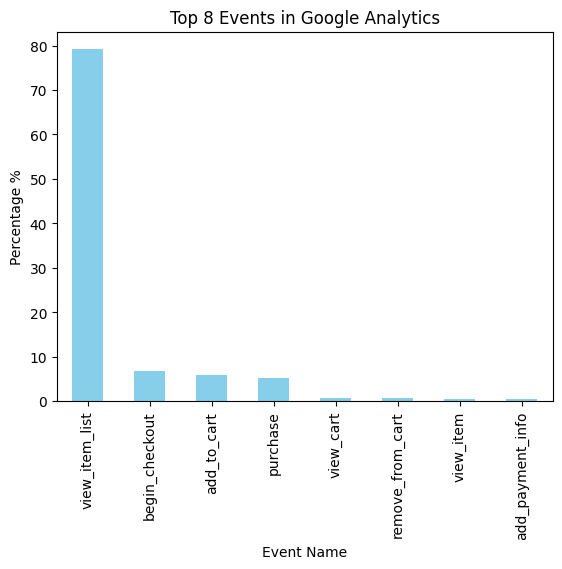

The 8 most common events in Google Analytics are:
event_name
view_item_list     79.1800
begin_checkout      6.7200
add_to_cart         5.8200
purchase            5.1300
view_cart           0.8300
remove_from_cart    0.7800
view_item           0.5600
add_payment_info    0.4000
Name: proportion, dtype: float64

This is an expected result as page views should be the most common metric as users visit the webpage.
Interestingly The update cart is higher than add cart.
This could reflect how users immediately add their next cart after placing their order and then adjusting accordingly based on their next shipment needs


In [49]:
top_events_ga = round(ga['event_name'].value_counts(normalize=True)*100,2).head(8)


top_events_ga.plot(kind='bar', title = 'Top 8 Events in Google Analytics', xlabel = 'Event Name', ylabel = 'Percentage %', color = 'skyblue')

plt.show()

print(f'The 8 most common events in Google Analytics are:\n{top_events_ga}\n')
print(f'This is an expected result as page views should be the most common metric as users visit the webpage.\nInterestingly The update cart is higher than add cart.\nThis could reflect how users immediately add their next cart after placing their order and then adjusting accordingly based on their next shipment needs')

### Viewing top 6 events split by device type

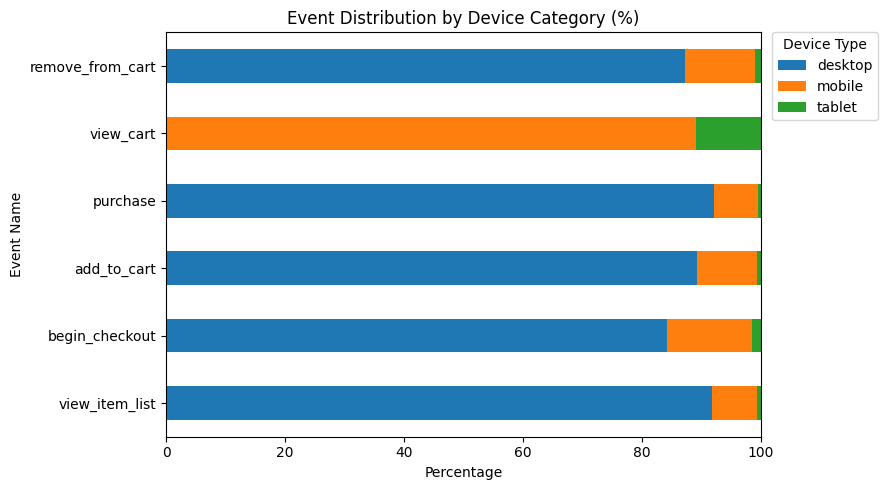

Customers are using desktops/computers to to make purchases, browse, view orders.
Mobile is used to a lesser extent whereas tablet is non existent.
Interestingly, out of all the events for mobile, the event with the highest mobile use is begin_checkout.
Customers use their phones to begin checkouts which starts the process of ordering


In [50]:


# 1) Choosing 6 events for this
top_event_names = ga['event_name'].value_counts().head(6).index

# 2) Filter to those events
ga_top = ga[ga['event_name'].isin(top_event_names)].copy()

# 3) Building the corss tabulation
ct = (pd.crosstab(ga_top['event_name'], ga_top['device_category'], normalize='index') * 100)

# 4) Ordering the columns
desired_order = ['desktop', 'mobile', 'tablet']
ct = ct.reindex(columns=[c for c in desired_order if c in ct.columns])

# 5) Sorting by volume
event_order = ga_top['event_name'].value_counts().loc[top_event_names].index
ct = ct.loc[event_order]

# 6) Plot as horizontal stacked bar chart
ax = ct.plot(
    kind='barh',
    stacked=True,
    figsize=(9, 5),
    title='Event Distribution by Device Category (%)'
)

ax.set_xlabel('Percentage')
ax.set_ylabel('Event Name')
ax.set_xlim(0, 100)
plt.xticks(rotation=0)

# 7) Placing the legend outside. I noticed previously it was ontop of the plot itself.
plt.legend(
    title='Device Type',
    bbox_to_anchor=(1.02, 1),  # just outside the right edge
    loc='upper left',
    borderaxespad=0.0
)

plt.tight_layout()
plt.show()


print(f'Customers are using desktops/computers to to make purchases, browse, view orders.\nMobile is used to a lesser extent whereas tablet is non existent.\nInterestingly, out of all the events for mobile, the event with the highest mobile use is begin_checkout.\nCustomers use their phones to begin checkouts which starts the process of ordering')


## 8.2) Orders

### Analyzing total orders across time by Quarter

/var/folders/g1/_r53jbfn2tg_0kcxz7b3cwg40000gn/T/ipykernel_86071/3585394245.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders['order_date'] = pd.to_datetime(orders['created_date_est'])
/var/folders/g1/_r53jbfn2tg_0kcxz7b3cwg40000gn/T/ipykernel_86071/3585394245.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders['order_quarter'] = orders['order_date'].dt.to_period('Q')


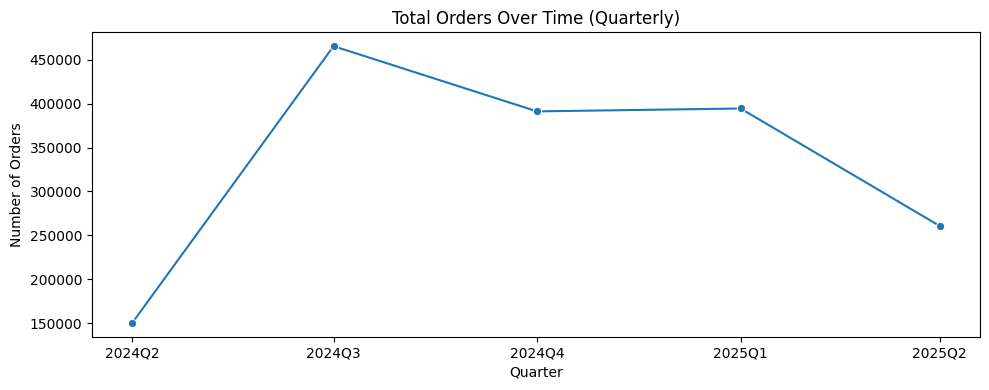

2024 Q3 had the highest number of orders.
The orders are declining from 2025. It would be interesting to compare 2025 Q3 to 2024 Q3 once that data is out.
Perhaps the orders would increase as per the trend observed the previous year?
 The analysis further emphasis the importance of answering the business problem as to understanding why carts/orders are being abandoned.


In [51]:
# First we will convert the order date column to datetime format
orders['order_date'] = pd.to_datetime(orders['created_date_est'])

# Create a new column for the quarter each order was placed in (e.g., 2024Q1, 2024Q2, etc.)
orders['order_quarter'] = orders['order_date'].dt.to_period('Q')

# Counting how many orders were placed in each quarter
order_trend_q = (
    orders
    .groupby('order_quarter')
    .size()
    .reset_index(name='num_orders')  # rename count column
    .sort_values('order_quarter')    # make sure it’s in order
)

# Make cleaner labels and a date to use for plotting
order_trend_q['quarter_label'] = order_trend_q['order_quarter'].astype(str)                  
order_trend_q['quarter_start'] = order_trend_q['order_quarter'].dt.start_time

# Plot the number of orders per quarter
plt.figure(figsize=(10, 4))
sns.lineplot(data=order_trend_q, x='quarter_start', y='num_orders', marker='o')

# Add title and axis labels
plt.title('Total Orders Over Time (Quarterly)')
plt.xlabel('Quarter')
plt.ylabel('Number of Orders')

# Use readable x-axis tick labels (Q1, Q2, etc.)
plt.xticks(
    ticks=order_trend_q['quarter_start'],
    labels=order_trend_q['quarter_label'],
    rotation=0
)

plt.tight_layout()
plt.show()


print(f'2024 Q3 had the highest number of orders.\nThe orders are declining from 2025. It would be interesting to compare 2025 Q3 to 2024 Q3 once that data is out.\nPerhaps the orders would increase as per the trend observed the previous year?\n The analysis further emphasis the importance of answering the business problem as to understanding why carts/orders are being abandoned.')

## 8-3) Sales

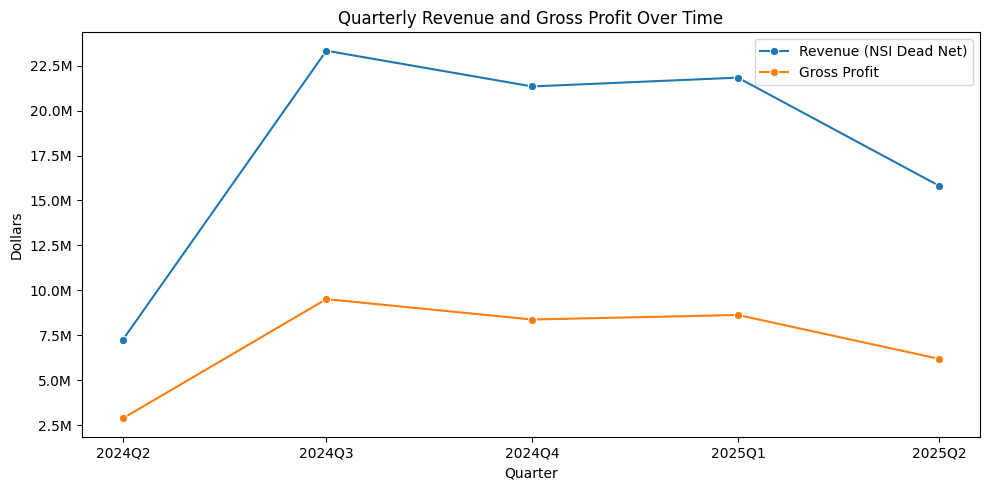

Revenue and Gross Profit appear to be declining compared to 2024.
This aligns with the earlier trend we saw in the drop in order volume.


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# Create quarter column
sales['quarter'] = sales['posting_date'].dt.to_period('Q')

# Summarize by quarter
revenue_trend_q = (
    sales
    .groupby('quarter')[['nsi_dead_net', 'gross_profit_dead_net']]
    .sum()
    .reset_index()
    .sort_values('quarter')
)

revenue_trend_q['quarter_start'] = revenue_trend_q['quarter'].dt.start_time

# Plot
plt.figure(figsize=(10, 5))

sns.lineplot(data=revenue_trend_q, x='quarter_start', y='nsi_dead_net',
             label='Revenue (NSI Dead Net)', marker='o')

sns.lineplot(data=revenue_trend_q, x='quarter_start', y='gross_profit_dead_net',
             label='Gross Profit', marker='o')

plt.title('Quarterly Revenue and Gross Profit Over Time')
plt.xlabel('Quarter')
plt.ylabel('Dollars')
plt.legend()

# Format Y-axis to use M (millions). Before it was showing it in scientific notation which i wanted to avoid.
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'))

# Quarter labels on X-axis
plt.xticks(
    ticks=revenue_trend_q['quarter_start'],
    labels=revenue_trend_q['quarter'].astype(str),
    rotation=0
)

plt.tight_layout()
plt.show()

print("Revenue and Gross Profit appear to be declining compared to 2024.\nThis aligns with the earlier trend we saw in the drop in order volume.")


### Finding the top 10 products by Revenue

/var/folders/g1/_r53jbfn2tg_0kcxz7b3cwg40000gn/T/ipykernel_86071/3846017573.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products_named, x='nsi_dead_net', y='trade_mark_desc', palette='Blues_d')


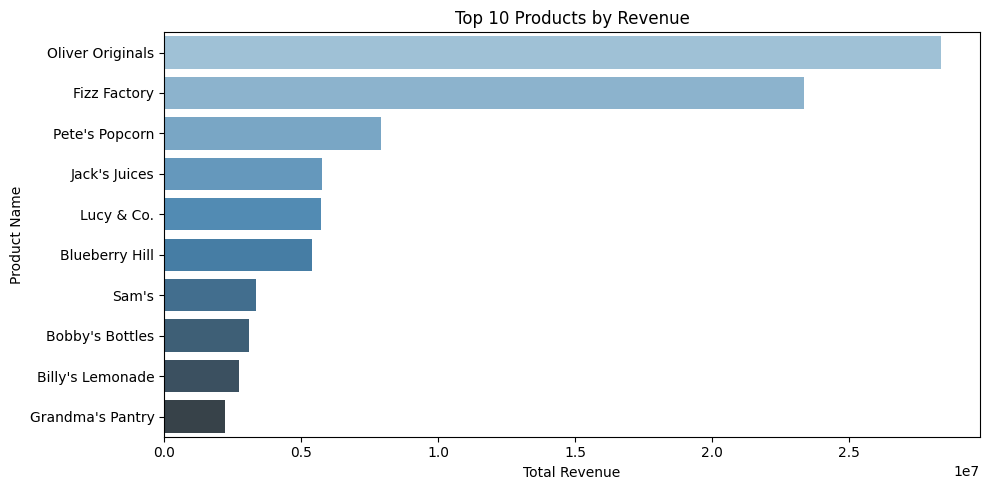

Olivers Originals has the highest revenue at $25 million, Followed by Fizz Factory and Petes Popcorn.
Grandmas Pantry is the product that has the least revenue


In [53]:
# for this we need to join the materials table with sales. This is because the material table has the products name (trade_mark_desc) whereas sales just has the materials id

sales_merged = pd.merge(
    sales,
    materials[['material_id', 'trade_mark_desc']],  # only pull what you need
    on='material_id',
    how='left'
)

# Grouping by product name/trade_mark_desc now instead of material_id
top_products_named = (
    sales_merged
    .groupby('trade_mark_desc')['nsi_dead_net']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
plt.figure(figsize=(10, 5))
sns.barplot(data=top_products_named, x='nsi_dead_net', y='trade_mark_desc', palette='Blues_d')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

print(f'Olivers Originals has the highest revenue at $25 million, Followed by Fizz Factory and Petes Popcorn.\nGrandmas Pantry is the product that has the least revenue')


### Finding top 10 products by Gross Profit



/var/folders/g1/_r53jbfn2tg_0kcxz7b3cwg40000gn/T/ipykernel_86071/2855552530.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


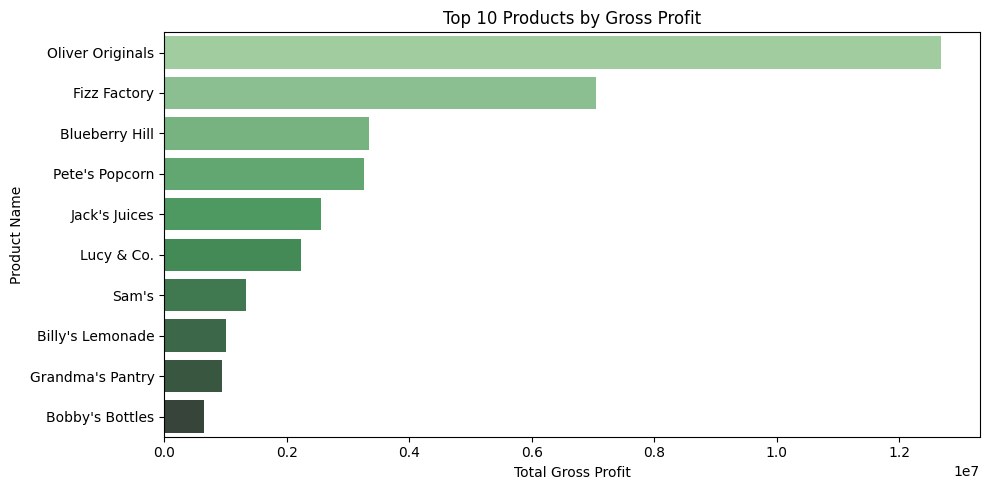

Oliver Originals is clearly the leader. It boosts the highest revenue & gross profit followed by Fizz Factory.
One fascinating observation is that blueberry hill is the 3rd leading product in terms of Gross profit, but in revenue its 6th in ranking.


In [54]:


# 3. Grouping by product name and sum gross profit this time
top_profit_products = (
    sales_merged
    .groupby('trade_mark_desc')['gross_profit_dead_net']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# 4. Now with the new DF i made i'll plot the Top 10 most profitable products
plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_profit_products,
    x='gross_profit_dead_net',
    y='trade_mark_desc',
    palette='Greens_d'
)
plt.title('Top 10 Products by Gross Profit')
plt.xlabel('Total Gross Profit')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

print(f'Oliver Originals is clearly the leader. It boosts the highest revenue & gross profit followed by Fizz Factory.\nOne fascinating observation is that blueberry hill is the 3rd leading product in terms of Gross profit, but in revenue its 6th in ranking.')


# 8.4) Visit Plan

### Average Frequency (How often a customer receives a delivery) by sales office

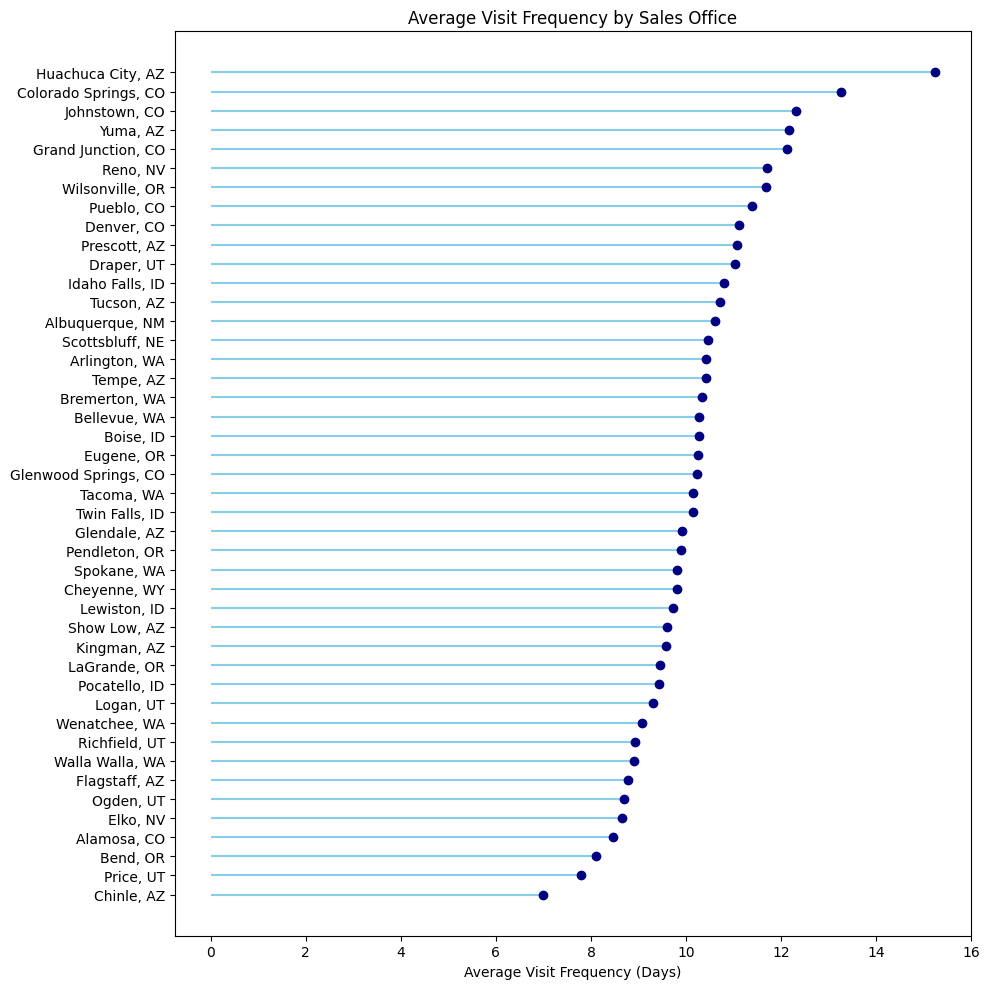

The sales office with the shortest frequency time is Chinle AZ. This means that customers that are assigned to Chinle AZ as their sales office are mostly ordering on a weekly basis.
In comparision, Huachucha City AZ has the longest frequency at 14 days. This means that customers on average in Huachuca are ordering biweekly


In [55]:
# Sort by frequency
vp_avg = visit_plan.groupby('sales_office_desc')['frequency'].mean().reset_index()
vp_avg = vp_avg.sort_values('frequency', ascending=True)

# Ploting as a lollipop chart
plt.figure(figsize=(10, 10))
plt.hlines(y=vp_avg['sales_office_desc'], xmin=0, xmax=vp_avg['frequency'], color='skyblue')
plt.plot(vp_avg['frequency'], vp_avg['sales_office_desc'], "o", color='navy')
plt.xlabel('Average Visit Frequency (Days)')
plt.title('Average Visit Frequency by Sales Office')
plt.tight_layout()
plt.show()

print(f'The sales office with the shortest frequency time is Chinle AZ. This means that customers that are assigned to Chinle AZ as their sales office are mostly ordering on a weekly basis.\nIn comparision, Huachucha City AZ has the longest frequency at 14 days. This means that customers on average in Huachuca are ordering biweekly')


## 8.5) Customers

### Finding our customer base

In [56]:

num_customers = customer['customer_number'].nunique()
print(f"Total unique customers: {num_customers:,}")


Total unique customers: 6,334


In [57]:
channel_counts = customer['cold_drink_channel_description'].value_counts()
display(channel_counts)


cold_drink_channel_description
Restaurant      2962
Store            739
Hot Beverage     655
Attraction       549
Hotel            351
Institution      338
Distributor      315
Workplace        298
Clinic           127
Name: count, dtype: int64

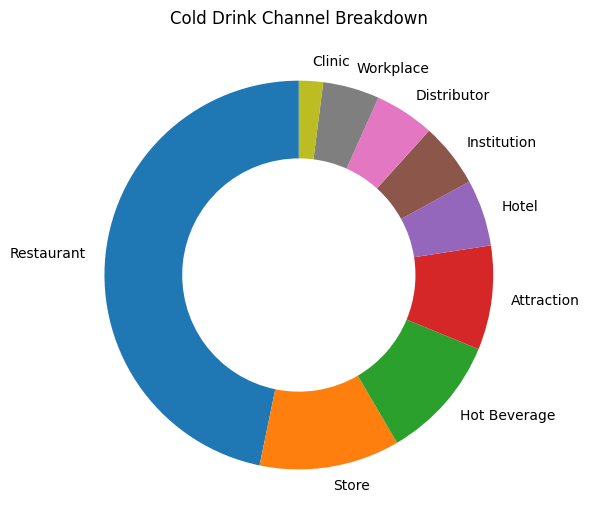

Most of our clinetele are restaurants followed by stores.
Workplaces and clinics are among our fewer clientele


In [58]:
plt.figure(figsize=(6, 6))
plt.pie(
    channel_counts,
    labels=channel_counts.index,
    startangle=90,
    wedgeprops={'width': 0.4},
)
plt.title('Cold Drink Channel Breakdown')
plt.tight_layout()
plt.show()

print(f'Most of our clinetele are restaurants followed by stores.\nWorkplaces and clinics are among our fewer clientele')


## 8.6) Order Cut off times

### Most common cut off times

In [59]:
cutoff_times.head()

,sales_office,plant_id,cutofftime__c,shipping_condition_time,distribution_mode
0,"Draper, UT",G111,6:00:00 PM,72,Tell Sell
1,"Draper, UT",G111,6:00:00 PM,48,Tell Sell
2,"Draper, UT",G111,1:30:00 PM,24,Tell Sell
3,"Draper, UT",G111,3:30:00 PM,24,OFS
4,"Draper, UT",G111,3:30:00 PM,24,Bulk Distribution


In [60]:
display(cutoff_times['cutofftime__c'].value_counts())

print(f'Most of our cutoff times for ordering is during the afternoon')


cutofftime__c
3:00:00 PM     36
3:30:00 PM     27
4:00:00 PM     26
11:00:00 AM    26
4:30:00 PM     25
12:00:00 PM    18
2:00:00 PM     17
10:00:00 AM    10
10:30:00 AM     9
1:30:00 PM      6
11:30:00 AM     4
1:00:00 PM      4
8:00:00 AM      3
2:30:00 PM      3
5:00:00 PM      3
6:00:00 PM      2
2:30:00 AM      1
Name: count, dtype: int64

Most of our cutoff times for ordering is during the afternoon


# Questions
## 1. How does cart abandonment vary by device type and how can it be reduced?


### Determining abandoment rate by device

In [61]:

# Grouping by customer, date and device
daily_device = (
    ga.groupby(['customer_id', 'event_date', 'device_category'])['event_name']
    .agg(list)
    .reset_index()
)

# Flags
daily_device['added_to_cart'] = daily_device['event_name'].apply(lambda x: 'add_to_cart' in x)
daily_device['purchased']     = daily_device['event_name'].apply(lambda x: 'purchase' in x)
daily_device['abandoned']     = (daily_device['added_to_cart']) & (~daily_device['purchased'])

# calculating the abandonment rate to see which device has the highest

abandon_by_device = (
    daily_device.groupby('device_category')[['added_to_cart', 'abandoned']]
    .sum().reset_index()
)

# Abandonment rate
abandon_by_device['abandon_rate'] = (
    abandon_by_device['abandoned'] / abandon_by_device['added_to_cart']
)

display(abandon_by_device)

,device_category,added_to_cart,abandoned,abandon_rate
0,desktop,30541,6917,0.2265
1,mobile,5080,2531,0.4982
2,tablet,270,125,0.4630


/var/folders/g1/_r53jbfn2tg_0kcxz7b3cwg40000gn/T/ipykernel_86071/3273178426.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=abandon_by_device, x='device_category', y='abandon_rate', palette='Set2')


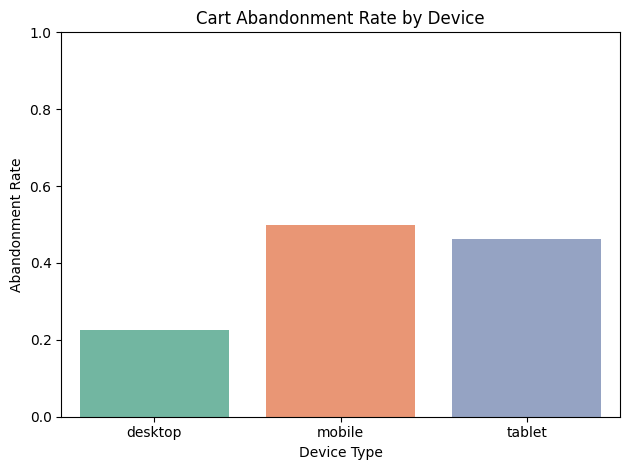

Mobile has the highest abandonment rate. This could be due to customers using their phones to browse the website before placing the order using their computer.
It could also be due to being distracted e.g from notifications. Also checkouts through mobile can be difficult especially when entering payment information.
Tablets have less of an abandonment rate whereas desktop has the least.


In [62]:
# Visualizing the devices via a barplot

sns.barplot(data=abandon_by_device, x='device_category', y='abandon_rate', palette='Set2')
plt.title('Cart Abandonment Rate by Device')
plt.ylabel('Abandonment Rate')
plt.xlabel('Device Type')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


print(f'Mobile has the highest abandonment rate. This could be due to customers using their phones to browse the website before placing the order using their computer.\nIt could also be due to being distracted e.g from notifications. Also checkouts through mobile can be difficult especially when entering payment information.\nTablets have less of an abandonment rate whereas desktop has the least.')

In [63]:
# Step 1: Funnel step order
funnel_steps = [
    'view_item_list',
    'view_item',
    'add_to_cart',
    'begin_checkout',
    'purchase'
]

# Step 2: Filter only events in those steps
funnel_df = ga[ga['event_name'].isin(funnel_steps)].copy()

# Step 3: Create a step-customer table
step_counts = (
    funnel_df
    .groupby(['event_name', 'customer_id'])  # per customer
    .size()
    .reset_index(name='count')
)

# Step 4: Count unique customers per step
funnel_summary = (
    step_counts
    .groupby('event_name')['customer_id']
    .nunique()
    .reindex(funnel_steps)  # keep logical order
    .reset_index(name='unique_users')
)

# Step 5: Calculate dropoff and conversion
funnel_summary['dropoff'] = funnel_summary['unique_users'].shift(1) - funnel_summary['unique_users']
funnel_summary['conversion_rate'] = (
    funnel_summary['unique_users'] / funnel_summary['unique_users'].shift(1)
).round(3)

display(funnel_summary)


,event_name,unique_users,dropoff,conversion_rate
0,view_item_list,4823,NaN,NaN
1,view_item,2897,1926.0000,0.6010
2,add_to_cart,4463,-1566.0000,1.5410
3,begin_checkout,4226,237.0000,0.9470
4,purchase,3816,410.0000,0.9030


Purchases occur in the following order: view_item_list -> view_item -> add_to_cart -> begin_checkout -> purchase

- view_item_list (4,823 unique clients):
These users browsed a product listing page, such as a category or search results.

- view_item (2,897 unique clients):
Around 60% of users who viewed a list actually clicked into a product to see more details. The rest dropped off, likely just browsing instead of buying. 

- add_to_cart (4,463 unique clients):
Surprisingly, more users added items to their cart than viewed individual products. This is likely because users can add directly from the list page without clicking into a product. It could be from the clientele who already know about the product and just want to add it to their cart immediately.

- begin_checkout (4,226 clients):
Most users who added to cart moved on to start the checkout process. There's only a small dropoff here, which suggests that cart behavior is intentional and checkout is fairly user friendly.

- purchase (3,816 clients):
Roughly 90% of users who began checkout completed the purchase, which is strong. The remaining 10% may have dropped off due to login issues, payment friction, or unclear delivery details.

### How to reduce abandonment by device

Given that mobile users have the highest abandonment there are a few strategies Swire can implement to reduce it.
1. Offer Email/Text message reminders to clients who abandon their carts
2. Likewise offer reminders for clients who have not added items to their carts when they are closer to their anchor date
3. Reduce back and forth cart navigation by streamlining the mobile webpage.
    - Expand Swire Connect to include ordering for B2B Customers
    - Swire connect currently offers communication information to customers. Adding options for existing customers to make purchases could boost mobile sales which can offset abandonment.

